# Isotropy & Anisotropy — Why Latent Spaces Collapse into a Narrow Cone

> **Goal:** *See* the difference between an isotropic latent space (a uniform sphere) and the
> anisotropic **narrow cone** that real Transformer-based models actually produce — and *feel*
> the four mechanisms that drag the geometry into that cone, the damage it does to distance and
> cosine similarity, and how whitening pulls it back.

An **isotropic** space spreads its embeddings evenly in every direction: maximal entropy, every
axis used, distances behave the way Euclidean intuition expects. The reality for most modern
models — especially LLMs — is **anisotropic**: vectors are crushed into a low-dimensional
sub-space pointing the same way, a phenomenon also called the **Representation Degeneration
Problem**. This notebook builds both geometries from scratch and re-derives, with code, every
claim the research file makes.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Sphere vs cone** | What does isotropy *look* like, and how do we put a number on it? |
| 2 | **Illusory cosine similarity** | Why do *unrelated* vectors score high cosine similarity in a cone? |
| 3 | **Self-attention contraction** | How does stacking attention layers squeeze angular variance toward one axis? |
| 4 | **Frequency-induced collapse** | Why do frequent tokens get pinned to the centre with tiny norm? |
| 5 | **Gradient rich-get-richer** | How does optimization amplify a few directions and starve the rest? |
| 6 | **Whitening remediation** | Can we restore isotropy — and should we always want to? |

---
**Linked theory:** [research/03-isotropy-anisotropy.md](../research/03-isotropy-anisotropy.md)  ·  **Chạy:** `uv run jupyter lab` từ thư mục `latent-anything-theory/` (cần các package trong `pyproject.toml`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from numpy.linalg import eigh, norm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete. NumPy:', np.__version__)

Setup complete. NumPy: 2.4.6


---
## A shared toolkit: two geometries and three isotropy meters

Every experiment leans on the same vocabulary, so we define it once.

- **Isotropic cloud** — a plain Gaussian: equal variance in every direction, centred on the origin.
- **Narrow-cone cloud** — the anisotropic foil. We add a large *common* offset $s\,u$ along a single
  unit direction $u$ (with a positive coefficient for every point) on top of a small isotropic
  residual. The shared offset is what forces all vectors to point roughly the same way.

Three numbers will recur:

1. **Partition isotropy** $I(X)=\dfrac{\min_{\|c\|=1}Z(c)}{\max_{\|c\|=1}Z(c)}$ with
   $Z(c)=\sum_i e^{c^\top x_i}$, approximated over the eigenvectors of $X^\top X$ (Arora/Mu).
   $I\!\to\!1$ means isotropic; $I\!\to\!0$ means a cone.
2. **Average random cosine similarity** — the mean cosine between *random pairs*. Near $0$ for a
   sphere; large and positive for a cone.
3. **Effective rank** $\big(\sum\lambda_k\big)^2/\sum\lambda_k^2$ on the covariance eigenvalues —
   how many directions are *actually* used.

In [2]:
D = 50          # ambient dimensionality
N = 2000        # number of embeddings


def make_isotropic(n, d, rng):
    """A clean isotropic Gaussian cloud centred at the origin."""
    return rng.standard_normal((n, d))


def make_cone(n, d, rng, strength=4.0, residual=0.10):
    """A narrow cone: a large, widely-varying offset along one axis + a tiny isotropic residual.

    The coefficient along u is both large (high cosine similarity) and high-variance (so u also
    dominates the *covariance* spectrum, not just the mean) -- a genuine low-rank cone.
    """
    res = residual * rng.standard_normal((n, d))
    u = rng.standard_normal(d)
    u /= norm(u)
    # every point gets a POSITIVE coefficient along u -> all vectors point the same general way
    coeff = strength * (0.15 + 0.85 * rng.random((n, 1)))
    return res + coeff * u


def cov_eigs(X):
    """Descending covariance eigenvalues of a cloud."""
    Xc = X - X.mean(axis=0)
    C = (Xc.T @ Xc) / len(X)
    w = np.linalg.eigvalsh(C)[::-1]
    return np.clip(w, 0, None)


def partition_isotropy(X):
    """Arora/Mu partition-function isotropy in [0, 1]; 1 = isotropic, 0 = cone.

    Uses the embeddings as-is (NOT mean-centred) -- the mean is exactly what makes a cone.
    """
    Xs = X / X.std()                       # scale only, keeps exp() well-behaved
    _, V = eigh(Xs.T @ Xs)                 # eigenvectors = candidate directions c
    Z = np.exp(Xs @ V).sum(axis=0)         # partition function along each direction
    return float(Z.min() / Z.max())


def random_cosines(X, rng, m=6000):
    """Cosine similarity of m random pairs of rows."""
    i = rng.integers(0, len(X), m)
    j = rng.integers(0, len(X), m)
    a, b = X[i], X[j]
    return (a * b).sum(1) / (norm(a, axis=1) * norm(b, axis=1) + 1e-12)


def effective_rank(eigs):
    """Participation ratio of an eigenvalue spectrum: how many axes are really used."""
    eigs = eigs[eigs > 0]
    return (eigs.sum() ** 2) / (np.sum(eigs ** 2) + 1e-12)


def softmax_rows(S):
    S = S - S.max(axis=1, keepdims=True)
    E = np.exp(S)
    return E / E.sum(axis=1, keepdims=True)


rng = np.random.default_rng(0)
X_iso = make_isotropic(N, D, rng)
X_cone = make_cone(N, D, rng)
print(f'isotropic  : partition I = {partition_isotropy(X_iso):.3f}'
      f'   effective rank = {effective_rank(cov_eigs(X_iso)):.1f} / {D}')
print(f'narrow cone: partition I = {partition_isotropy(X_cone):.3f}'
      f'   effective rank = {effective_rank(cov_eigs(X_cone)):.1f} / {D}')

isotropic  : partition I = 0.690   effective rank = 48.8 / 50
narrow cone: partition I = 0.000   effective rank = 2.3 / 50


### What you see

The two clouds live in the same 50-dimensional space, yet their numbers could not be more different.
The isotropic cloud reports a high partition isotropy (around 0.7 for a finite Gaussian sample) and
an effective rank close to the full 50 — it genuinely uses every direction. The cone reports an
isotropy crushed toward 0 and an effective rank of only a handful: despite 50 available axes, almost
all the structure lives along the single shared direction $u$. Keep these two reference clouds in
mind — every later experiment is a different way of *producing* or *detecting* the cone.

---
## Experiment 1: Sphere vs cone — isotropy as a picture and as a spectrum

**Question:** Before any single mechanism, what does the degeneration actually *look* like? If we
project both clouds onto their top-2 principal axes and inspect the full eigenvalue spectrum, an
isotropic space should look like a round blob with a **flat** spectrum, while the cone should look
like a thin sliver with **one dominant eigenvalue** swallowing the rest.

The eigenvalue spectrum of the covariance is the cleanest x-ray of isotropy: flat = energy shared
across directions, spiked = energy hoarded by a few.

In [3]:
np.random.seed(1)


def pca_2d(X):
    Xc = X - X.mean(axis=0)
    _, V = eigh(Xc.T @ Xc)
    return Xc @ V[:, ::-1][:, :2]            # top-2 components


P_iso = pca_2d(X_iso)
P_cone = pca_2d(X_cone)
eig_iso = cov_eigs(X_iso)
eig_cone = cov_eigs(X_cone)

print('top-5 normalized eigenvalues (fraction of total variance):')
print('  isotropic :', np.round(eig_iso[:5] / eig_iso.sum(), 3))
print('  cone      :', np.round(eig_cone[:5] / eig_cone.sum(), 3))

top-5 normalized eigenvalues (fraction of total variance):
  isotropic : [0.027 0.025 0.025 0.025 0.025]
  cone      : [0.661 0.009 0.009 0.009 0.009]


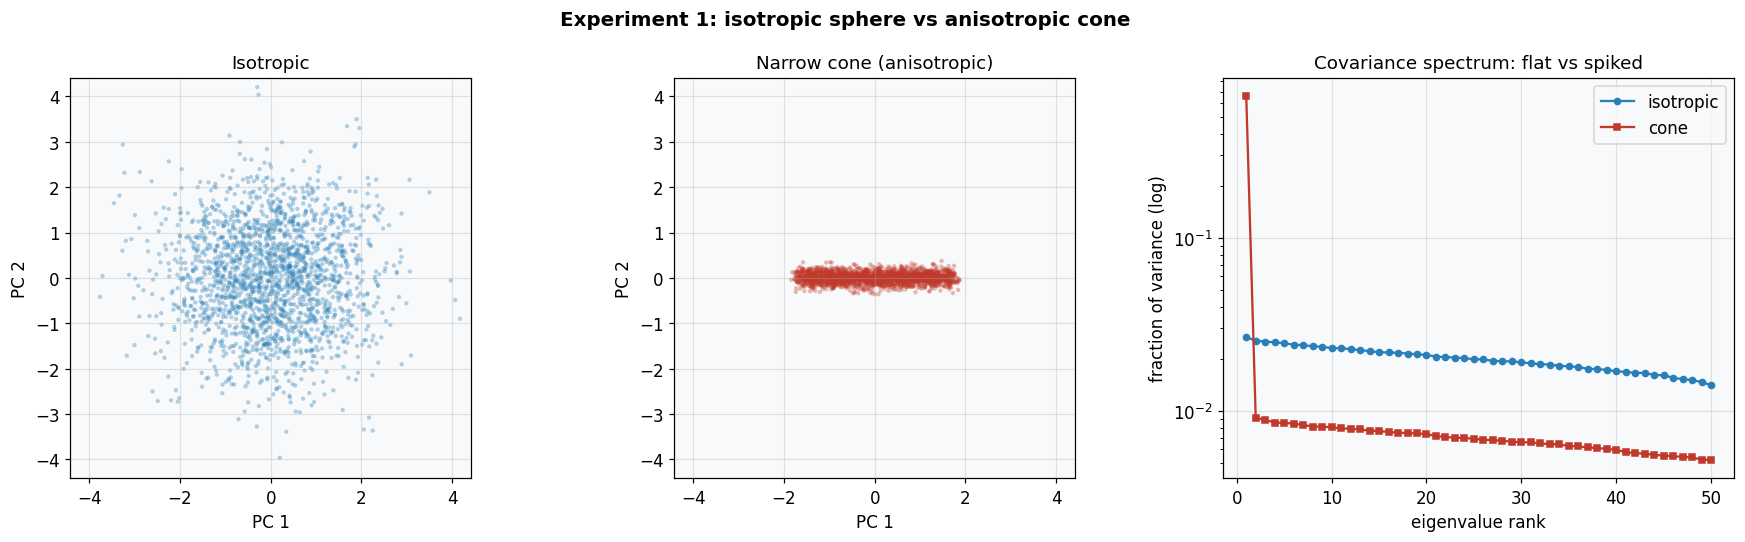

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5))
fig.suptitle('Experiment 1: isotropic sphere vs anisotropic cone', fontsize=13, fontweight='bold')

# --- top-2 PCA scatter, shared axis scale so the shapes are comparable ---
lim = np.abs(np.vstack([P_iso, P_cone])).max() * 1.05
for ax, P, name, col in [(axes[0], P_iso, 'Isotropic', '#2980b9'),
                         (axes[1], P_cone, 'Narrow cone (anisotropic)', '#c0392b')]:
    ax.scatter(P[:, 0], P[:, 1], s=8, alpha=0.35, color=col, edgecolors='none')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
    ax.set_title(name)

# --- eigenvalue spectra ---
ax = axes[2]
k = np.arange(1, D + 1)
ax.plot(k, eig_iso / eig_iso.sum(), 'o-', color='#2980b9', ms=4, label='isotropic')
ax.plot(k, eig_cone / eig_cone.sum(), 's-', color='#c0392b', ms=4, label='cone')
ax.set_yscale('log')
ax.set_xlabel('eigenvalue rank')
ax.set_ylabel('fraction of variance (log)')
ax.set_title('Covariance spectrum: flat vs spiked')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The isotropic cloud (left) is a round, symmetric disk — no preferred
   direction. The cone (middle) is a thin streak: virtually all spread lies along PC 1, with PC 2
   almost flat. The spectrum (right) makes it quantitative — the isotropic curve is nearly flat
   (every direction carries a similar slice of variance), while the cone dumps almost all variance
   into the first eigenvalue and decays orders of magnitude below it.

2. **Why it looks this way:** The offset along $u$ we injected is large *and* highly variable, so $u$
   carries the lion's share of the variance; the tiny residual fills the other 49 axes with crumbs. The
   covariance therefore has one dominant eigenvalue sitting on a flat floor — the algebraic signature of
   a "narrow cone" living in a sub-space of much lower effective dimension than the ambient 50.

3. **Key takeaway:** Isotropy is readable straight off the eigenvalue spectrum. Real LLM embedding
   matrices show exactly this spiked shape — a handful of "rogue" dominant directions over a low
   floor — which is why naive Euclidean and cosine geometry (built next) misbehave on them.

---
## Experiment 2: Illusory cosine similarity — why unrelated vectors look "similar"

**Question:** The research file's first negative consequence is *high cosine similarity*: in a cone,
even semantically unrelated vectors register a high cosine score. If we sample many **random pairs**
from each cloud and histogram their cosine similarity, the isotropic distribution should sit centred
on $0$, while the cone's should be shoved far to the positive side.

Cosine similarity is the cosine of the angle between two vectors. In a narrow cone all vectors share
roughly the same heading, so every pairwise angle is small and every cosine is large — regardless of
meaning.

In [5]:
np.random.seed(2)
rng2 = np.random.default_rng(2)

cos_iso = random_cosines(X_iso, rng2)
cos_cone = random_cosines(X_cone, rng2)

print(f'isotropic  : mean random cosine = {cos_iso.mean():+.3f}   std = {cos_iso.std():.3f}')
print(f'narrow cone: mean random cosine = {cos_cone.mean():+.3f}   std = {cos_cone.std():.3f}')

isotropic  : mean random cosine = -0.003   std = 0.143
narrow cone: mean random cosine = +0.845   std = 0.112


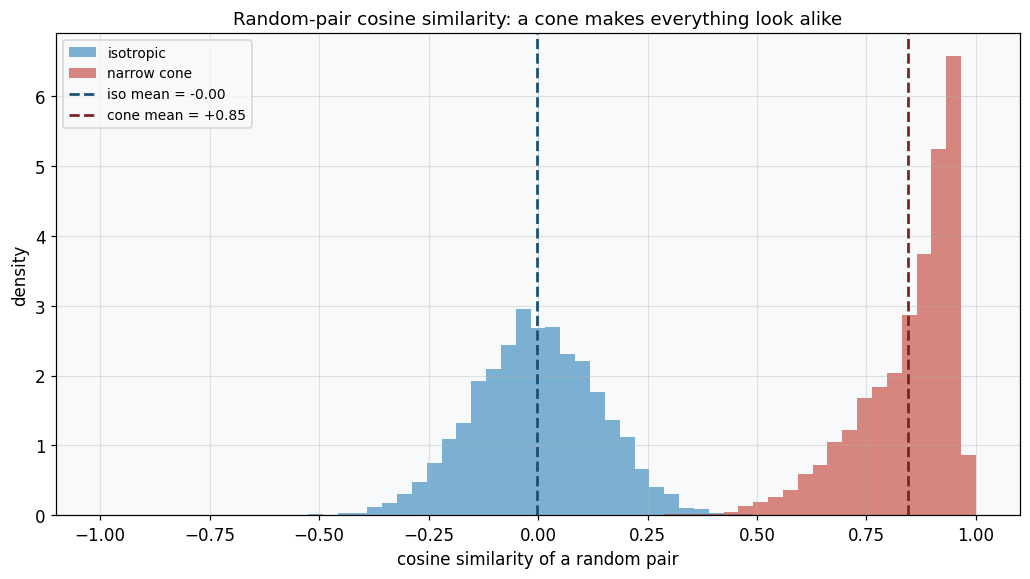

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 5.4))
bins = np.linspace(-1, 1, 60)
ax.hist(cos_iso, bins=bins, alpha=0.6, color='#2980b9', label='isotropic', density=True)
ax.hist(cos_cone, bins=bins, alpha=0.6, color='#c0392b', label='narrow cone', density=True)
ax.axvline(cos_iso.mean(), color='#1b4f72', ls='--', lw=1.8,
           label=f'iso mean = {cos_iso.mean():+.2f}')
ax.axvline(cos_cone.mean(), color='#7b241c', ls='--', lw=1.8,
           label=f'cone mean = {cos_cone.mean():+.2f}')
ax.set_xlabel('cosine similarity of a random pair')
ax.set_ylabel('density')
ax.set_title('Random-pair cosine similarity: a cone makes everything look alike')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The isotropic histogram is a tight bell centred on $0$ — two random
   vectors are, on average, orthogonal, exactly as high-dimensional geometry predicts. The cone's
   histogram is shifted hard to the right, piling up near high positive cosine values with a mean far
   above zero.

2. **Why it looks this way:** Every point in the cone is dominated by the shared component along $u$,
   so any two of them differ only by their tiny residuals. The angle between them is therefore small
   and the cosine close to 1 — *even though the residuals (the part that could carry meaning) are
   independent random noise*. The high similarity is an artefact of the geometry, not of any real
   relationship.

3. **Key takeaway:** This is the "illusory high cosine similarity" of the Representation Degeneration
   Problem. In an anisotropic space a cosine score of, say, 0.8 means almost nothing — it is the
   baseline for *any* pair. Semantic comparisons must first remove the dominant directions, which is
   precisely what Experiment 6 does.

---
## Experiment 3: Self-attention contraction — stacking layers squeezes the cone

**Question:** The research file's first *cause* is that self-attention acts as a **contraction
operator on angular variance**: each layer pulls vectors toward a weighted average, and dozens of
stacked layers grind them onto a central axis. If we start from a loosely-spread cloud (only a mild
directional bias) and repeatedly apply a self-attention update, do the points contract into a narrow
cone, and does the average pairwise cosine climb toward 1?

A self-attention layer replaces each token by a softmax-weighted combination of all tokens —
a *convex* mixing. Convex mixing can only ever pull points inward, never push them apart, so its
repeated application is contractive.

In [7]:
np.random.seed(3)
rng3 = np.random.default_rng(3)


def attention_step(X, beta=0.6, alpha=0.09):
    """One self-attention block: a residual step that moves each row a fraction alpha toward the
    softmax(beta * X Xᵀ)-weighted average of all rows. A mild beta keeps the averaging near-global,
    so the update is contractive toward the cloud's centroid."""
    S = beta * (X @ X.T)
    A = softmax_rows(S)
    return X + alpha * (A @ X - X)


# Start from a mild, OFF-CENTRE cloud in 2D (nonzero mean) so the convex averaging converges
# onto a ray from the origin -- a cone -- rather than collapsing to the origin itself.
u0 = np.array([1.0, 0.6]); u0 /= norm(u0)
X = 0.7 * u0 + 1.0 * make_isotropic(300, 2, rng3)
snapshots = {0: X.copy()}
mean_cos, ang_std = [], []
for layer in range(1, 41):
    X = attention_step(X)
    if layer in (10, 40):
        snapshots[layer] = X.copy()
    c = random_cosines(X, rng3, m=4000)
    mean_cos.append(c.mean())
    ang = np.arctan2(X[:, 1], X[:, 0])
    ang_std.append(np.std(np.angle(np.exp(1j * (ang - ang.mean())))))

print(f'layer  1 : mean pairwise cosine = {mean_cos[0]:.3f}')
print(f'layer 40 : mean pairwise cosine = {mean_cos[-1]:.3f}')

layer  1 : mean pairwise cosine = 0.270
layer 40 : mean pairwise cosine = 0.999


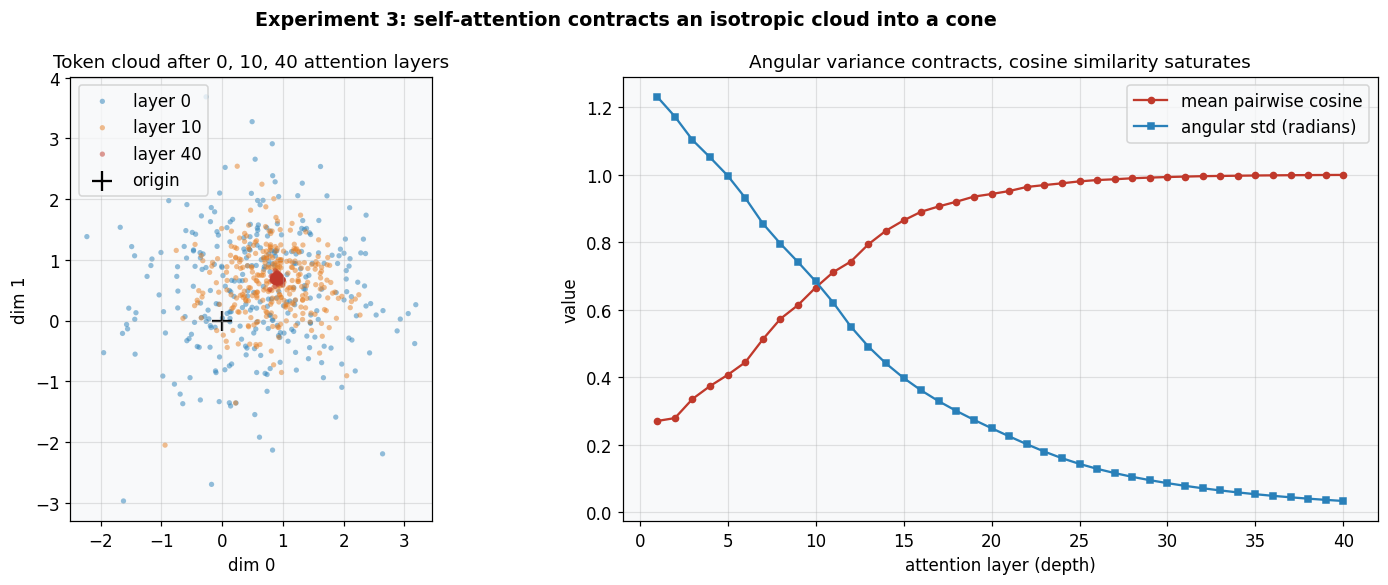

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
fig.suptitle('Experiment 3: self-attention contracts an isotropic cloud into a cone',
             fontsize=12.5, fontweight='bold')

# --- left: snapshots at layers 0, 8, 40 ---
ax = axes[0]
colors = {0: '#2980b9', 10: '#e67e22', 40: '#c0392b'}
for layer, snap in snapshots.items():
    ax.scatter(snap[:, 0], snap[:, 1], s=12, alpha=0.5,
               color=colors[layer], label=f'layer {layer}', edgecolors='none')
ax.scatter(0, 0, marker='+', s=160, color='black', label='origin')
ax.set_aspect('equal')
ax.set_xlabel('dim 0'); ax.set_ylabel('dim 1')
ax.set_title('Token cloud after 0, 10, 40 attention layers')
ax.legend()

# --- right: contraction curves ---
ax = axes[1]
layers = np.arange(1, 41)
ax.plot(layers, mean_cos, 'o-', color='#c0392b', ms=4, label='mean pairwise cosine')
ax.plot(layers, ang_std, 's-', color='#2980b9', ms=4, label='angular std (radians)')
ax.set_xlabel('attention layer (depth)')
ax.set_ylabel('value')
ax.set_title('Angular variance contracts, cosine similarity saturates')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The starting cloud (blue) is loosely spread with only a mild lean. After
   10 layers (orange) it has bunched noticeably; after 40 layers (red) it is a tight wedge pointing one
   way away from the origin. On the right, the average pairwise cosine climbs steadily toward 1 while
   the angular standard deviation decays toward 0 — the two signatures of a cone forming.

2. **Why it looks this way:** Each attention step replaces a token with a softmax-weighted *average*
   of all tokens. Averaging is a convex operation: the output always lies inside the convex hull of
   the inputs, so spread can only shrink. Stack the operation dozens of times and the cloud is
   squeezed monotonically toward the dominant weighted-mean direction — angular variance is
   *contracted* away exactly as the theory states.

3. **Key takeaway:** Anisotropy is not a bug bolted onto Transformers; it is baked into the core
   averaging mechanism. Depth, which makes models powerful, is the very thing that drives the
   representation toward a degenerate cone — which is why residual connections, normalization, and
   explicit isotropy penalties exist to fight back.

---
## Experiment 4: Frequency-induced variance collapse — frequent tokens pinned to the centre

**Question:** The research file's second cause is **token frequency**: common tokens ("the", "a",
"is") get their variance crushed and their norm shrunk, anchored near a central point, while rare
tokens stay spread out. If we give tokens Zipfian frequencies and let frequent ones absorb many
small centring updates, does norm fall with frequency and do frequent tokens collapse to the middle?

Under cross-entropy training a token's embedding is nudged on *every* occurrence; very frequent
tokens therefore receive a flood of updates whose average pull is toward the global centroid,
damping their norm and their room to move.

In [9]:
np.random.seed(4)
rng4 = np.random.default_rng(4)

V = 1200                                   # vocabulary size
ranks = np.arange(1, V + 1)
freq = 1.0 / ranks                         # Zipf's law: frequency ~ 1 / rank
freq /= freq.sum()
log_freq = np.log10(freq)

emb = rng4.standard_normal((V, D))         # initial isotropic embeddings
# centring pull proportional to how often a token is updated (its frequency)
pull = (freq / freq.max()) ** 0.5          # in [0, 1], saturating for frequent tokens
emb_trained = emb * (1.0 - 0.9 * pull[:, None])

token_norm = norm(emb_trained, axis=1)
print(f'most frequent token  norm = {token_norm[0]:.2f}')
print(f'least frequent token norm = {token_norm[-1]:.2f}')
print(f'partition isotropy of the embedding matrix = {partition_isotropy(emb_trained):.3f}')

most frequent token  norm = 0.72
least frequent token norm = 6.31
partition isotropy of the embedding matrix = 0.644


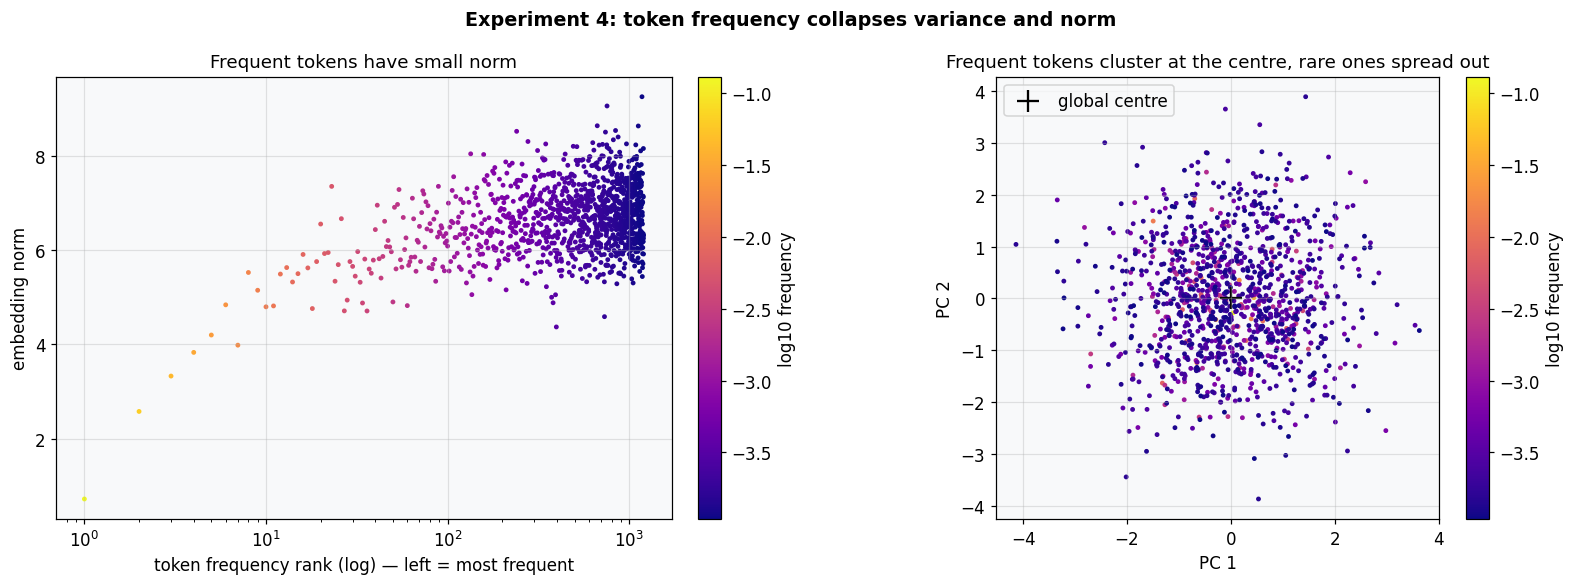

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))
fig.suptitle('Experiment 4: token frequency collapses variance and norm',
             fontsize=12.5, fontweight='bold')

# --- left: norm vs frequency rank ---
ax = axes[0]
sc = ax.scatter(ranks, token_norm, c=log_freq, cmap='plasma', s=10, edgecolors='none')
ax.set_xscale('log')
ax.set_xlabel('token frequency rank (log) — left = most frequent')
ax.set_ylabel('embedding norm')
ax.set_title('Frequent tokens have small norm')
cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cb.set_label('log10 frequency')

# --- right: PCA scatter coloured by frequency ---
ax = axes[1]
P = pca_2d(emb_trained)
sc = ax.scatter(P[:, 0], P[:, 1], c=log_freq, cmap='plasma', s=10, edgecolors='none')
ax.scatter(0, 0, marker='+', s=200, color='black', label='global centre')
ax.set_aspect('equal')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title('Frequent tokens cluster at the centre, rare ones spread out')
ax.legend()
cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cb.set_label('log10 frequency')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** On the left, embedding norm rises steadily from the most frequent tokens
   (small norm, far left) to the rarest (large norm) — a clear frequency–norm anti-correlation. On the
   right, the bright high-frequency tokens are huddled tightly around the black centre marker, while
   the dark rare tokens fan out to the periphery.

2. **Why it looks this way:** A token that appears constantly is pushed and pulled on nearly every
   training step; the net of all those competing gradients is a strong, persistent pull toward the
   common centroid, which both shrinks its norm and pins its variance. Rare tokens are touched seldom,
   so they keep their initial spread. The frequency imbalance of natural language is therefore *directly*
   stamped into the geometry as variance collapse.

3. **Key takeaway:** Much of an LLM's anisotropy is donated by a small set of ultra-frequent function
   words sitting in a tiny high-density core. This is why simply *removing the mean* (dominated by those
   frequent tokens) recovers a surprising amount of isotropy — the trick we apply in Experiment 6.

---
## Experiment 5: Gradient rich-get-richer — a few directions eat the rest

**Question:** The third cause is a **gradient bias toward dominant directions**: a direction that
already carries a little more signal attracts more gradient, grows, and attracts still more — a
self-reinforcing loop that flattens the space into a cone. If we evolve a spectrum of eigenvalues
under a rich-get-richer rule, does one direction run away while the effective rank collapses?

The key quantity is the **effective rank** (participation ratio): it counts how many directions
genuinely carry variance. A healthy isotropic space keeps it high; the runaway loop should drive it
toward 1.

In [11]:
np.random.seed(5)
rng5 = np.random.default_rng(5)

lam = 1.0 + 0.05 * rng5.standard_normal(D)        # nearly-flat start, tiny random edge
lam = np.clip(lam, 0.2, None)
eta = 0.18                                         # amplification rate

history, eff_rank = [lam.copy()], [effective_rank(lam)]
for step in range(60):
    share = lam / lam.sum()                        # bigger directions get a bigger share...
    lam = lam * (1.0 + eta * share * D)            # ...and are amplified more (rich get richer)
    lam /= lam.mean()                              # keep total energy bounded
    history.append(lam.copy())
    eff_rank.append(effective_rank(lam))

print(f'effective rank: start = {eff_rank[0]:.1f} / {D}   ->   end = {eff_rank[-1]:.1f} / {D}')

effective rank: start = 49.9 / 50   ->   end = 1.0 / 50


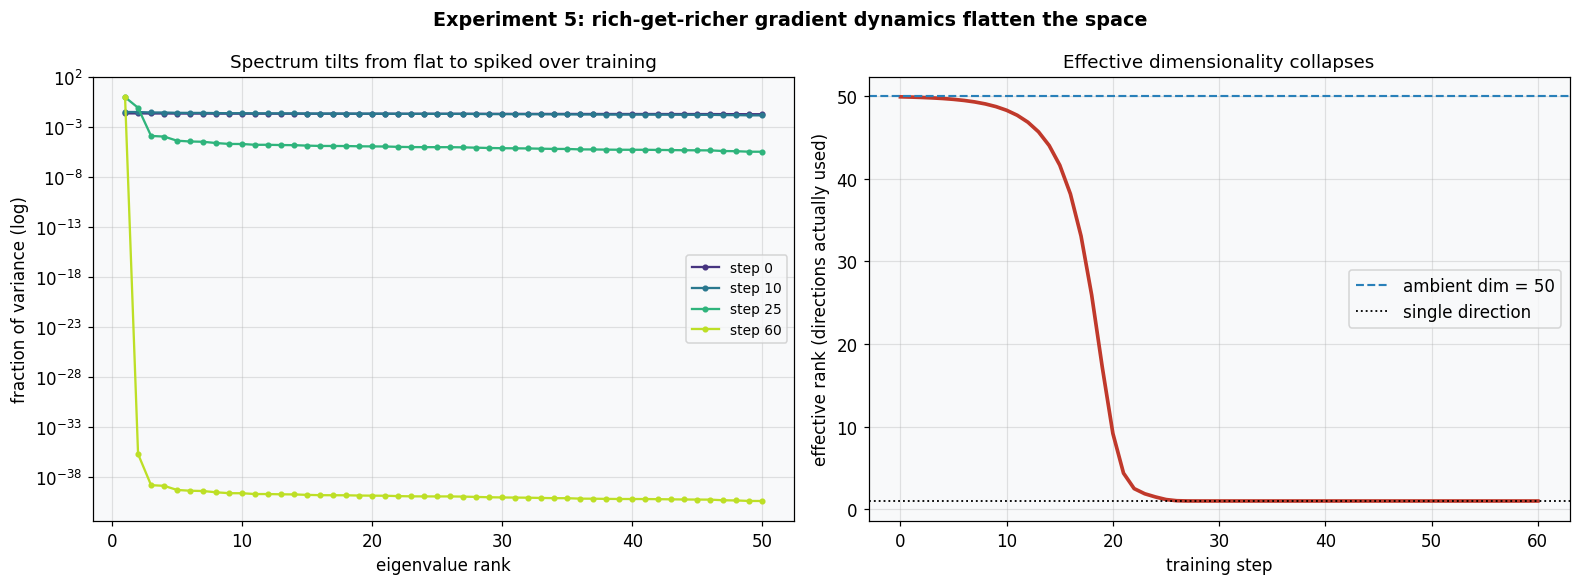

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))
fig.suptitle('Experiment 5: rich-get-richer gradient dynamics flatten the space',
             fontsize=12.5, fontweight='bold')

# --- left: spectrum at several training steps ---
ax = axes[0]
steps_to_show = [0, 10, 25, 60]
cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(steps_to_show)))
ranks = np.arange(1, D + 1)
for c, s in zip(cmap, steps_to_show):
    sorted_lam = np.sort(history[s])[::-1]
    ax.plot(ranks, sorted_lam / sorted_lam.sum(), 'o-', ms=3, color=c, label=f'step {s}')
ax.set_yscale('log')
ax.set_xlabel('eigenvalue rank')
ax.set_ylabel('fraction of variance (log)')
ax.set_title('Spectrum tilts from flat to spiked over training')
ax.legend(fontsize=9)

# --- right: effective rank vs step ---
ax = axes[1]
ax.plot(np.arange(len(eff_rank)), eff_rank, '-', color='#c0392b', lw=2.4)
ax.axhline(D, color='#2980b9', ls='--', lw=1.4, label=f'ambient dim = {D}')
ax.axhline(1, color='black', ls=':', lw=1.2, label='single direction')
ax.set_xlabel('training step')
ax.set_ylabel('effective rank (directions actually used)')
ax.set_title('Effective dimensionality collapses')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The spectrum starts almost flat (step 0, nearly equal variance per axis)
   and progressively tilts: by step 60 the top eigenvalue towers orders of magnitude above the rest.
   On the right, the effective rank falls from near the full ambient dimension toward a handful of
   directions — the space is using fewer and fewer axes.

2. **Why it looks this way:** The update rule amplifies each direction in proportion to the share of
   variance it already holds. A direction that begins with even a hair more variance grabs a slightly
   larger update, which enlarges its share, which enlarges its next update — positive feedback. Weaker
   directions are correspondingly starved and shrink. This is exactly the "tangent directions amplified,
   normal directions suppressed" feedback loop the research file describes.

3. **Key takeaway:** Anisotropy can emerge from optimization dynamics *alone*, with no architectural
   help — a generic instability of gradient training on imbalanced data. It also hints at the *positive*
   reading: this is implicit dimensionality reduction, concentrating signal onto a few axes that often
   align with reusable structure such as syntax.

---
## Experiment 6: Whitening remediation — pulling the cone back to a sphere (should we?)

**Question:** Finally, the fix. Two cheap post-hoc transforms target the cone directly:
**all-but-the-top** (remove the mean and the few dominant principal components) and **ZCA whitening**
(rescale every direction to unit variance). Do they restore the partition isotropy and re-centre the
cosine distribution — and what does the research file warn we might lose by doing so?

Whitening equalizes the eigenvalue spectrum by construction, so it is the most aggressive isotropizer;
all-but-the-top is a gentler surgical removal of just the rogue directions.

In [13]:
np.random.seed(6)
rng6 = np.random.default_rng(6)


def all_but_the_top(X, k=2):
    """Subtract the mean and project out the top-k principal directions."""
    Xc = X - X.mean(axis=0)
    _, V = eigh(Xc.T @ Xc)
    top = V[:, ::-1][:, :k]
    return Xc - (Xc @ top) @ top.T


def zca_whiten(X):
    """Mean-centre then rescale all directions to unit variance (ZCA)."""
    Xc = X - X.mean(axis=0)
    C = (Xc.T @ Xc) / len(X)
    w, V = eigh(C)
    W = V @ np.diag(1.0 / np.sqrt(np.clip(w, 1e-6, None))) @ V.T
    return Xc @ W


X_abtt = all_but_the_top(X_cone, k=2)
X_white = zca_whiten(X_cone)

rows = [('original cone', X_cone), ('all-but-top (k=2)', X_abtt), ('ZCA whitened', X_white)]
iso_scores = {name: partition_isotropy(Xv) for name, Xv in rows}
cos_after = {name: random_cosines(Xv, rng6) for name, Xv in rows}
for name, Xv in rows:
    print(f'{name:20s}: isotropy = {iso_scores[name]:.3f}   '
          f'mean random cosine = {cos_after[name].mean():+.3f}')

original cone       : isotropy = 0.000   mean random cosine = +0.846
all-but-top (k=2)   : isotropy = 0.510   mean random cosine = -0.001
ZCA whitened        : isotropy = 0.957   mean random cosine = -0.001


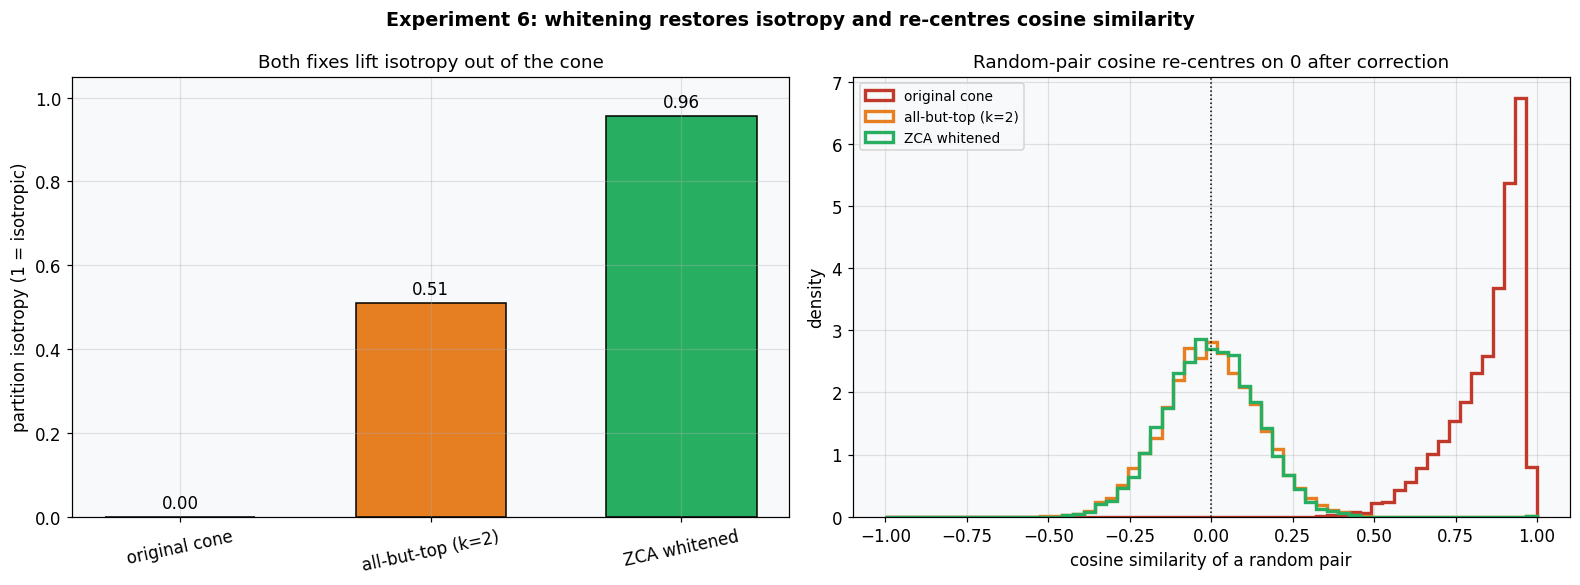

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))
fig.suptitle('Experiment 6: whitening restores isotropy and re-centres cosine similarity',
             fontsize=12.5, fontweight='bold')

# --- left: isotropy bars before/after ---
ax = axes[0]
names = list(iso_scores.keys())
vals = [iso_scores[n] for n in names]
cols = ['#c0392b', '#e67e22', '#27ae60']
bars = ax.bar(names, vals, color=cols, edgecolor='black', width=0.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f'{v:.2f}', ha='center', fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('partition isotropy (1 = isotropic)')
ax.set_title('Both fixes lift isotropy out of the cone')
ax.tick_params(axis='x', labelrotation=12)

# --- right: cosine distributions before/after ---
ax = axes[1]
bins = np.linspace(-1, 1, 60)
for n, c in zip(names, cols):
    ax.hist(cos_after[n], bins=bins, density=True, histtype='step', lw=2.2, color=c, label=n)
ax.axvline(0, color='black', ls=':', lw=1)
ax.set_xlabel('cosine similarity of a random pair')
ax.set_ylabel('density')
ax.set_title('Random-pair cosine re-centres on 0 after correction')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The original cone has near-zero partition isotropy and a cosine
   distribution shoved far to the right. All-but-the-top lifts isotropy substantially by deleting just
   two rogue directions; ZCA whitening pushes it close to 1. On the right, both corrected
   distributions snap back to a bell centred on $0$ — random pairs are orthogonal again.

2. **Why it looks this way:** Almost all the cone's anisotropy lived in a single shared direction
   (Experiment 1). Removing the mean and the top components excises exactly that rogue axis, and
   whitening goes further by equalizing *every* eigenvalue to 1, manufacturing a flat spectrum by
   construction. Once the dominant direction is gone, cosine similarity again reflects only the residual
   (potentially meaningful) structure.

3. **Key takeaway — and the caveat:** Isotropization is cheap and it repairs distance and cosine
   geometry. But the research file's *positive* view warns against over-correcting: the cone often
   *stores* syntactic regularities and acts as implicit denoising, so forcing perfect isotropy can erase
   useful structure and hurt downstream tasks. The goal is to widen the cone enough to restore
   measurable geometry **without** flattening away the structure the model learned — a balance, not a
   blanket whitening.

---
## Summary

| Experiment | Theme | Key insight |
|---|---|---|
| 1. Sphere vs cone | Foundation | Isotropy is readable off the covariance spectrum: flat = sphere, one giant eigenvalue = narrow cone |
| 2. Illusory cosine | Consequence | In a cone, random unrelated vectors score high cosine similarity — the metric becomes nearly meaningless |
| 3. Attention contraction | Cause | Self-attention averages tokens convexly; stacked depth contracts angular variance into a cone |
| 4. Frequency collapse | Cause | Zipf-frequent tokens absorb the most updates, shrinking their norm and pinning them to the centre |
| 5. Rich-get-richer | Cause | Gradient dynamics amplify already-dominant directions, collapsing the effective rank toward 1 |
| 6. Whitening | Remediation | All-but-the-top and ZCA restore isotropy and re-centre cosine — but risk erasing useful structure |

### The big picture

Latent spaces are **not** the uniform spheres our Euclidean intuition assumes. Self-attention's
convex averaging, the heavy tail of token frequencies, and the rich-get-richer bias of gradient
descent conspire to crush embeddings into a low-dimensional **narrow cone** — the Representation
Degeneration Problem. That cone inflates cosine similarity, distorts nearest-neighbour distance, and
steals probability mass. Yet the very same compression performs implicit dimensionality reduction and
hoards reusable structure such as syntax, which is why the models still work. Remediation
(all-but-the-top, whitening, contrastive or simplicial stretching) should therefore aim to *widen* the
cone enough to recover trustworthy geometry — the prerequisite for any **manipulation** of latent
space this project cares about — without flattening away what the model worked so hard to learn.